<a href="https://colab.research.google.com/github/sayim665/atml-pa0/blob/main/task3_clip/task3_clip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3 — CLIP Tasks

ATML PA0 — Task 3

Sections:
1. Zero-shot classification on STL-10 (3 prompting strategies)
2. Exploring the modality gap
3. Bridging the modality gap (Procrustes alignment)

## Setup

In [2]:
!pip install -q git+https://github.com/openai/CLIP.git ftfy regex scikit-learn scipy matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00


In [3]:


import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import clip
from torchvision import datasets
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Available CLIP models:", clip.available_models())

os.makedirs("results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

Using device: cuda
Available CLIP models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


In [4]:
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print("Loaded CLIP ViT-B/32")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 236MiB/s]


Loaded CLIP ViT-B/32


## Data — STL-10

In [5]:

stl_test = datasets.STL10(root="../data", split="test", download=True, transform=preprocess)

stl_classes = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck",
]
print(len(stl_test), "test images,", len(stl_classes), "classes")

100%|██████████| 2.64G/2.64G [23:21<00:00, 1.88MB/s]


8000 test images, 10 classes


## 1. Zero-Shot Classification on STL-10

In [6]:
# Three prompting strategies
prompt_templates = {
    "plain": lambda c: c,
    "photo_of": lambda c: f"a photo of a {c}",
    "descriptive": lambda c: f"a high-quality photo of a {c}, a common object seen in everyday life",
}

In [7]:
@torch.no_grad()
def build_text_features(template_fn, classes):
    texts = [template_fn(c) for c in classes]
    tokens = clip.tokenize(texts).to(device)
    text_features = model.encode_text(tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features


@torch.no_grad()
def evaluate_zero_shot(loader, text_features):
    correct, total = 0, 0
    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        image_features = model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ text_features.T  # (batch, num_classes)
        preds = similarity.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


from torch.utils.data import DataLoader
stl_loader = DataLoader(stl_test, batch_size=128, shuffle=False, num_workers=0)

zero_shot_results = {}
for name, template_fn in prompt_templates.items():
    text_feats = build_text_features(template_fn, stl_classes)
    acc = evaluate_zero_shot(stl_loader, text_feats)
    zero_shot_results[name] = acc
    print(f"{name}: {acc:.4f}")

  0%|          | 0/63 [00:00<?, ?it/s]

plain: 0.9626


  0%|          | 0/63 [00:00<?, ?it/s]

photo_of: 0.9736


  0%|          | 0/63 [00:00<?, ?it/s]

descriptive: 0.9671


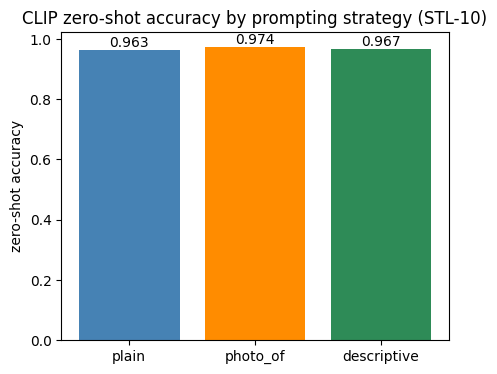

In [8]:
plt.figure(figsize=(5,4))
names = list(zero_shot_results.keys())
accs = list(zero_shot_results.values())
plt.bar(names, accs, color=["steelblue", "darkorange", "seagreen"])
plt.ylabel("zero-shot accuracy")
plt.title("CLIP zero-shot accuracy by prompting strategy (STL-10)")
for i, a in enumerate(accs):
    plt.text(i, a + 0.01, f"{a:.3f}", ha="center")
plt.savefig("../figures/task3_zero_shot_prompting.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion:** Compare accuracy across the three prompting strategies. Why might more descriptive/templated prompts help?

> All three prompt strategies did pretty well here, all sitting above 96%, which on its own says a lot about how strong CLIP's zero-shot ability is, given it was never trained on STL-10 at all. That said, there's still a class whuch came out on top: "a photo of" at 97.4% beating both the plain label (96.3%) and the longer, more descriptive prompt (97.4%). The reason it wins probably comes down to matching CLIP's training data. CLIP was trained on real image caption pairs scraped from the internet, and captions in the wild tend to be short, natural phrases like "a photo of a dog" rather than either a single bare word or an unusually long, elaborate description. So a plain label like "cat" is a bit too sparse; it doesn't look like the kind of caption CLIP actually saw during training, while our more descriptive prompt ("a high-quality photo of a cat, a common object seen in everyday life") probably overshoots in the other direction, adding extra wording that doesn't really match typical caption style either. The templated version sits right in the middle, which is likely why it performed best, it looks the most like the kind of text CLIP was actually trained to associate with images. Basically, more descriptive isn't automatically better; what matters more is how closely the prompt resembles the natural captions the model learned from.


## 2. Exploring the Modality Gap

In [9]:
N_SAMPLES = 100

from torch.utils.data import Subset
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(stl_test), size=N_SAMPLES, replace=False)
sample_subset = Subset(stl_test, sample_idx)
sample_loader = DataLoader(sample_subset, batch_size=32, shuffle=False, num_workers=0)

@torch.no_grad()
def extract_image_embeddings(loader):
    feats, labels_all = [], []
    for images, labels in loader:
        images = images.to(device)
        f = model.encode_image(images)
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu().numpy())
        labels_all.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labels_all)

image_embeds, sample_labels = extract_image_embeddings(sample_loader)

# Corresponding text embeddings: use each image's true class label as its "caption"
text_feats_photo = build_text_features(prompt_templates["photo_of"], stl_classes)
text_embeds = text_feats_photo.cpu().numpy()[sample_labels]  # one text embedding per image, matched by class

print("image_embeds:", image_embeds.shape, "text_embeds:", text_embeds.shape)

image_embeds: (100, 512) text_embeds: (100, 512)


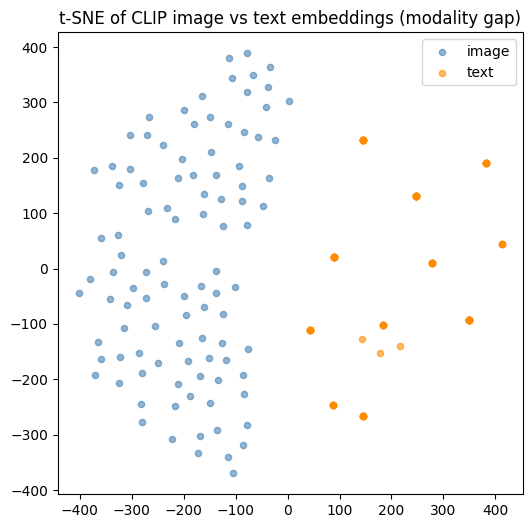

In [10]:
from sklearn.manifold import TSNE

combined = np.concatenate([image_embeds, text_embeds], axis=0)
modality = np.array(["image"]*len(image_embeds) + ["text"]*len(text_embeds))

emb2d = TSNE(n_components=2, init="pca", random_state=0, perplexity=30).fit_transform(combined)

plt.figure(figsize=(6,6))
for m, color in zip(["image", "text"], ["steelblue", "darkorange"]):
    mask = modality == m
    plt.scatter(emb2d[mask, 0], emb2d[mask, 1], label=m, alpha=0.6, s=20, color=color)
plt.legend()
plt.title("t-SNE of CLIP image vs text embeddings (modality gap)")
plt.savefig("../figures/task3_modality_gap_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:

img_centroid = image_embeds.mean(axis=0)
txt_centroid = text_embeds.mean(axis=0)
centroid_gap = np.linalg.norm(img_centroid - txt_centroid)

matched_cos_sim = (image_embeds * text_embeds).sum(axis=1).mean()  # matched image-text pairs

print(f"Centroid distance (image vs text): {centroid_gap:.4f}")
print(f"Mean cosine similarity of matched image-text pairs: {matched_cos_sim:.4f}")

Centroid distance (image vs text): 1.0479
Mean cosine similarity of matched image-text pairs: 0.2627


**Discussion:**
- How separated are the two modalities?
- Does normalization affect the modality gap?
- Why does CLIP still perform well despite this gap?

> Looking at the t-SNE plot, the separation is pretty stark, the blue (image) points sit almost entirely on the left side, while the orange (text) points cluster off to the right, with basically no mixing between the two groups. The numbers back this up: the centroid distance between the average image embedding and average text embedding is 1.05, which is a big gap considering these are unit-normalized vectors (max possible distance is 2, and two totally random vectors would typically land around 1.4 apart). Even more telling is the cosine similarity for genuinely matched pairs: an actual cat photo compared against the text "a photo of a cat", which only averages 0.26. That's a long way from 1.0, which is what you'd expect if the model treated a matching image and caption as basically pointing in the same direction.
As for normalization, both sets of embeddings here were already L2-normalized (unit vectors), which is standard for CLIP since its whole training setup is built around cosine similarity. Normalizing removes any difference in vector length between the two modalities, but it doesn't do anything about the direction they're pointing in, and that's exactly where the gap shows up. So the separation isn't some leftover artifact of one modality having bigger numbers than the other; it's a genuine directional offset baked into the embedding space itself, and normalization doesn't erase it.
Given all that, it might seem surprising that CLIP still classifies almost everything correctly, but that's because zero-shot classification doesn't need the matched pair's similarity to be close to 1. It just needs the correct class's similarity to be higher than every other class's similarity for that same image. Even at a modest 0.26 average, that's still consistently higher than the similarity to the wrong classes' text embeddings, which is all the model actually needs to pick the right one. So the modality gap is more like a fixed offset sitting between the two spaces, it doesn't line up images and captions on top of each other, but it doesn't scramble the relative ordering of similarities either, and that relative ordering is really all zero-shot classification is built on.

## 3. Bridging the Modality Gap (Procrustes Alignment)

In [12]:
from scipy.linalg import orthogonal_procrustes

# X = image embeddings, Y = text embeddings (matched pairs from Section 2)
X = image_embeds  # (N, 512)
Y = text_embeds    # (N, 512)

R, scale = orthogonal_procrustes(X, Y)
X_aligned = X @ R

print("Rotation matrix R shape:", R.shape)
print("Frobenius norm before alignment:", np.linalg.norm(X - Y))
print("Frobenius norm after alignment:", np.linalg.norm(X_aligned - Y))

Rotation matrix R shape: (512, 512)
Frobenius norm before alignment: 12.15
Frobenius norm after alignment: 5.1022377


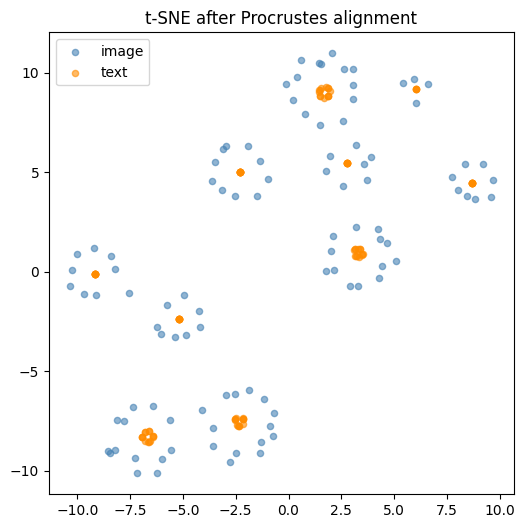

In [13]:
combined_aligned = np.concatenate([X_aligned, Y], axis=0)
emb2d_aligned = TSNE(n_components=2, init="pca", random_state=0, perplexity=30).fit_transform(combined_aligned)

plt.figure(figsize=(6,6))
for m, color in zip(["image", "text"], ["steelblue", "darkorange"]):
    mask = modality == m
    plt.scatter(emb2d_aligned[mask, 0], emb2d_aligned[mask, 1], label=m, alpha=0.6, s=20, color=color)
plt.legend()
plt.title("t-SNE after Procrustes alignment")
plt.savefig("../figures/task3_modality_gap_aligned_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:


@torch.no_grad()
def evaluate_zero_shot_aligned(loader, text_features_np, R):
    correct, total = 0, 0
    text_features = torch.tensor(text_features_np, device=device, dtype=torch.float32)
    R_t = torch.tensor(R, device=device, dtype=torch.float32)
    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        image_features = model.encode_image(images).float()
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        image_features_aligned = image_features @ R_t

        similarity = image_features_aligned @ text_features.T
        preds = similarity.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

text_feats_photo_np = text_feats_photo.cpu().numpy()
acc_before = zero_shot_results["photo_of"]
acc_after = evaluate_zero_shot_aligned(stl_loader, text_feats_photo_np, R)

print(f"Zero-shot accuracy BEFORE alignment: {acc_before:.4f}")
print(f"Zero-shot accuracy AFTER alignment:  {acc_after:.4f}")

  0%|          | 0/63 [00:00<?, ?it/s]

Zero-shot accuracy BEFORE alignment: 0.9736
Zero-shot accuracy AFTER alignment:  0.9686


**Discussion:** How does the Procrustes alignment affect the modality gap, and did it improve or hurt zero-shot accuracy? Why might that be?

> The alignment clearly did what it was supposed to on the geometry side, the Frobenius norm between the image and text embeddings dropped from 12.15 down to 5.10, more than halved, and the t-SNE plot after alignment backed this up visually too: instead of two separate blobs, you get ten tight little clusters, each with a text embedding sitting right in the middle surrounded by its matching images. So geometrically, the modality gap really did shrink a lot.
But that improvement didn't carry over to classification accuracy, if anything, it went slightly the other way, dropping from 97.36% before alignment to 96.86% after. The most likely explanation is overfitting: the rotation matrix R was only fit using 100 image-text pairs (10 per class), so while it does a great job of pulling those specific 100 points together, it's tuned to the particular quirks of that small sample rather than the full 8,000-image test set. When applied more broadly, a rotation learned from so little data doesn't generalize quite as well, so some images end up slightly worse aligned than they would've been without any rotation at all.
It's also worth pointing out that the drop was small, and the starting point was already really strong (97.36%) zero-shot accuracy left very little room for a geometric fix to meaningfully improve things, especially one that's at risk of overfitting to begin with. So the bigger takeaway here isn't really "alignment failed", it's that visually/geometrically closing the modality gap and improving actual task performance aren't necessarily the same thing. A rotation can make embeddings look much better aligned in a plot without translating into better classification, particularly when it's been learned from a sample too small to represent the full data distribution well.
